In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/raw/bp_readings.csv", sep=";")
df = df.dropna(axis=1, how="all")

In [ ]:
# O dataset carregou corretamente?
df.head()

,date,period,time,systolic,diastolic
0,2026-02-27,morning,07:00,129,69
1,2026-02-27,night,18:00,146,84
2,2026-02-27,night,20:00,125,62
3,2026-02-28,morning,07:00,132,80
4,2026-02-28,night,22:00,142,77


In [4]:
# Retorna um objeto chamado Index, uma estrutura que guarda os rótulos das colunas.
df.columns

Index(['date', 'period', 'time', 'systolic', 'diastolic'], dtype='str')

In [5]:
df.index

RangeIndex(start=0, stop=45, step=1)

In [6]:
# Retorna os tipos das colunas
df.dtypes

date           str
period         str
time           str
systolic     int64
diastolic    int64
dtype: object

In [7]:
df["date"] = pd.to_datetime(df["date"])
df["period"] = df["period"].astype("category")
df["systolic"] = df["systolic"].astype(int)
df["diastolic"] = df["diastolic"].astype(int)

In [8]:
df["timestamp"] = pd.to_datetime(
    df["date"].astype(str) + " " + df["time"]
)

In [9]:
df.dtypes

date         datetime64[us]
period             category
time                    str
systolic              int64
diastolic             int64
timestamp    datetime64[us]
dtype: object

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   date       45 non-null     datetime64[us]
 1   period     45 non-null     category      
 2   time       45 non-null     str           
 3   systolic   45 non-null     int64         
 4   diastolic  45 non-null     int64         
 5   timestamp  45 non-null     datetime64[us]
dtypes: category(1), datetime64[us](2), int64(2), str(1)
memory usage: 1.9 KB


In [11]:
df.describe()

,date,systolic,diastolic,timestamp
count,45,45.000000,45.000000,45
mean,2026-03-09 22:24:00,123.844444,62.155556,2026-03-10 12:23:40
min,2026-02-27 00:00:00,108.000000,36.000000,2026-02-27 07:00:00
25%,2026-03-04 00:00:00,116.000000,57.000000,2026-03-04 08:00:00
50%,2026-03-10 00:00:00,123.000000,63.000000,2026-03-10 19:00:00
75%,2026-03-16 00:00:00,129.000000,64.000000,2026-03-16 07:30:00
max,2026-03-22 00:00:00,146.000000,84.000000,2026-03-22 11:30:00
std,NaN,8.772259,8.212949,NaN


In [12]:
# Conta quantos valores faltantes existem em cada coluna.
df.isna().sum()

date         0
period       0
time         0
systolic     0
diastolic    0
timestamp    0
dtype: int64

In [13]:
df.nunique()

date         24
period        2
time         23
systolic     24
diastolic    21
timestamp    45
dtype: int64

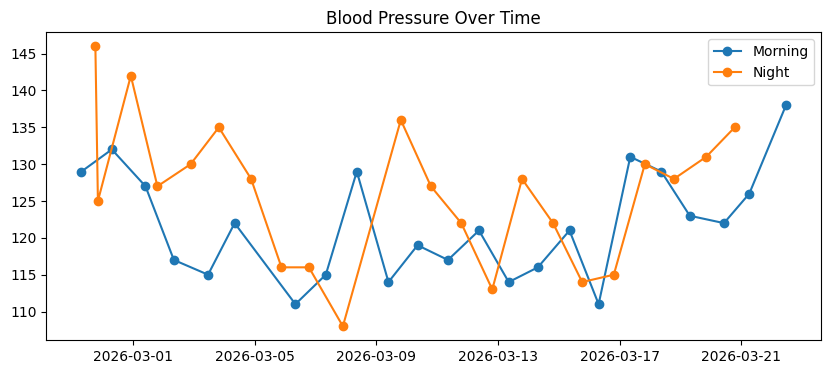

In [15]:
plt.figure(figsize=(10,4))

morning = df[df["period"] == "morning"]
night = df[df["period"] == "night"]

plt.plot(morning["timestamp"], morning["systolic"], marker="o", label="Morning")
plt.plot(night["timestamp"], night["systolic"], marker="o", label="Night")

plt.title("Blood Pressure Over Time")
plt.legend()

plt.show()